## About Dataset

#### Context
- "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

#### Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents   

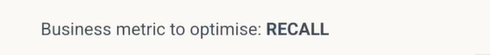   

Recall: Of all customers who will churn in real, how many did we correctly identify?   

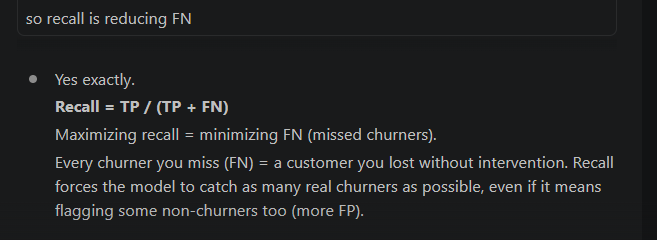

## Exploration & Data loading

In [125]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [126]:
df = pd.read_csv('..\\data\\raw\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [127]:
df1 = pd.read_csv('..\\data\\raw\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df1.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [128]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)     # Show all rows in the DataFrame

In [129]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### See if there is any missing values or outliers that is called exploration layers.

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [131]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


- Based on the .describe (and exploration) we can see that most categorical variables have between 2, 3, or 4 categories 
- So for those that only have 2 (binary) let's just replace by 0 and 1
- For those that have 3 or 4 we can do One-Hot encoding

In [132]:
{col: df[col].unique().tolist() for col in df.columns if df[col].nunique() == 2}

{'gender': ['Female', 'Male'],
 'SeniorCitizen': [0, 1],
 'Partner': ['Yes', 'No'],
 'Dependents': ['No', 'Yes'],
 'PhoneService': ['No', 'Yes'],
 'PaperlessBilling': ['Yes', 'No'],
 'Churn': ['No', 'Yes']}

## Binary Encoding

In [133]:
# Binary categorical columns (2 unique values)
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'
]

# Map Yes/No and Male/Female to 0/1
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})


In [134]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [135]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [136]:
[col for col in df.columns if 2 < df[col].nunique() <= 10]


['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [137]:
[col for col in df.columns if df[col].nunique() > 10]


['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']

## One-Hot encoding   

#### After pd.get_dummies() on OnlineSecurity, you get 3 columns:


* OnlineSecurity_Yes
* OnlineSecurity_No
* OnlineSecurity_No internet service


#### With drop_first=True (used in training), OnlineSecurity_No gets dropped as the reference category, leaving only:


* OnlineSecurity_Yes
* OnlineSecurity_No internet service

In [138]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [139]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   object 
 10  Churn                                  7043 non-null   int64  
 11  Mult

## Cleaning

* TotalCharges column in the CSV is stored as text (string), not numbers. Some rows have blank/invalid values.
* Below line converts it to a numeric type — invalid values (blanks, spaces) become NaN instead of crashing.

In [141]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


In [142]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [143]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


#### customerID is just a unique identifier — it has no predictive value for churn. If left in, the model might overfit to it (memorize IDs instead of learning patterns). It's dropped so only meaningful features are used for training.

In [144]:
df = df.drop('customerID', axis=1)

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [146]:
bool_cols = df.select_dtypes(include='bool').columns

* Finds all columns in the DataFrame that have a boolean data type (True/False).

* After pd.get_dummies(), some columns come out as bool instead of int (0/1). XGBoost can't handle booleans, so this line identifies them so the next line can convert them to integers.

In [147]:
bool_cols

Index(['MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [148]:
# Converts True/False to 1/0 for all boolean cols
df[bool_cols] = df[bool_cols].astype(int) 

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int32  
 11  Mult

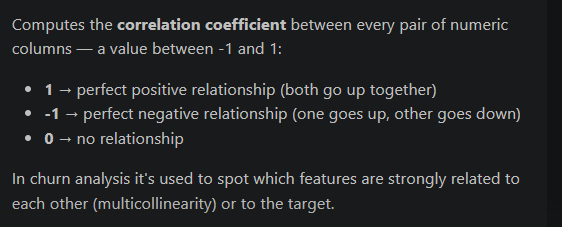

In [150]:
corr_matrix = df.corr(numeric_only=True)
# corr_matrix

* Below cell extracts just the Churn column from the correlation matrix — so you get the correlation of every other feature against Churn specifically — then sorts them from strongest positive to strongest negative correlation.
* Output tells you which features are the best predictors of churn at a glance.

In [151]:
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


#### Most likely to churn (positive correlation):  

* Fiber optic internet (0.31) — higher-cost service, more likely to switch
* Electronic check payment (0.30) — less committed payment method
* High monthly charges (0.19) — price-sensitive customers
* Paperless billing + Senior citizen — slightly higher risk

#### Electronic check payment : It's a digital version of a paper check — the customer manually enters their bank account details each time (or authorizes a one-time pull). It signals low commitment compared to automatic payments (credit card/bank transfer auto-pay), which is why it correlates with churn — customers who haven't set up autopay are already less engaged with the service.

#### Least likely to churn (negative correlation):

* Long tenure (-0.35) — the longer they stay, the more loyal they are
* Two-year contract (-0.30) — locked in, won't leave
* Online security / Tech support (-0.17) — customers getting value from services stay longer
* Has partner / dependents (-0.15) — more stable life situation   

#### Bottom line: A new customer on fiber optic, paying by electronic check, month-to-month contract with high monthly charges and short tenure = highest churn risk. This matches the Gradio UI example hardcoded in the app.



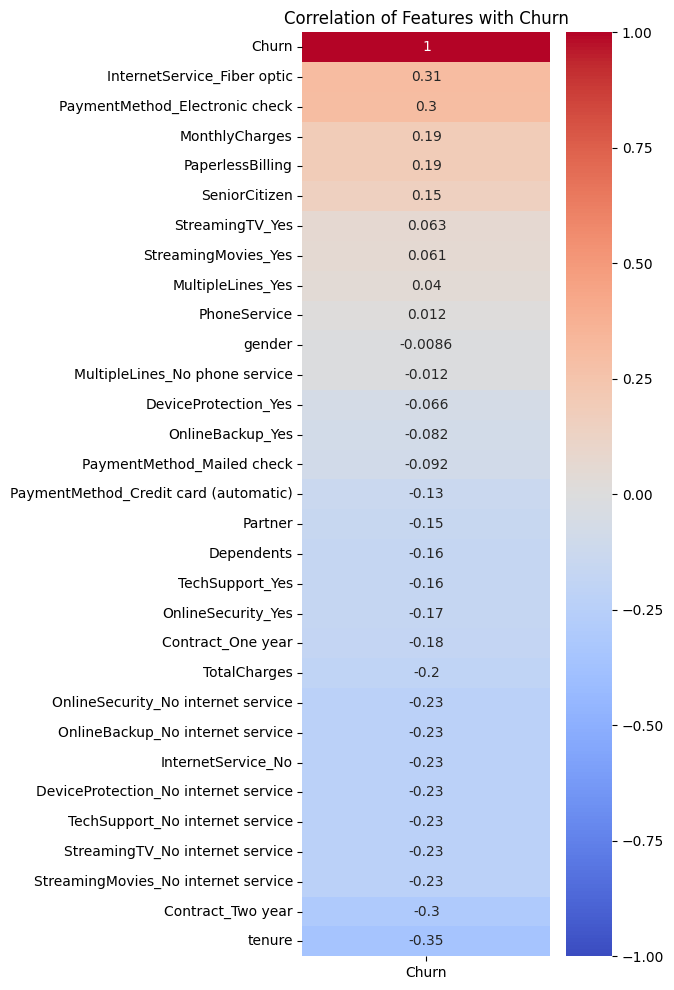

In [152]:
# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()


Negative (lower value → less likely to churn):

- tenure (-0.35) → Customers who stay longer are less likely to churn.
- Contract_Two year (-0.30) → Customers on long-term contracts churn much less.
- Contract_One year (-0.18) → Same trend but weaker than two-year contracts.

Positive (higher value → more likely to churn):

- InternetService_Fiber optic (+0.31) → Fiber optic users churn more in this dataset.
- PaymentMethod_Electronic check (+0.30) → Customers paying electronically via check churn more.

## Look for multicolinearity (VIF)   

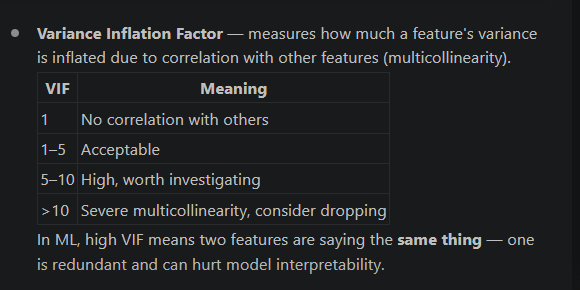  

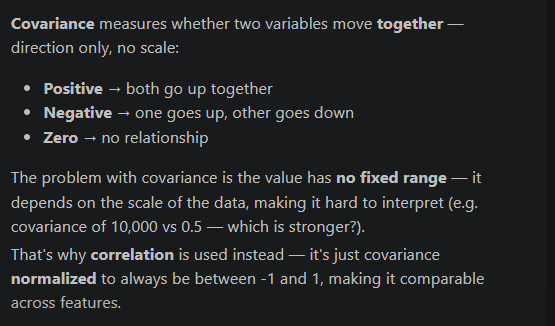

In [153]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [154]:
df['MultipleLines_No phone service'].value_counts()

MultipleLines_No phone service
0    6361
1     682
Name: count, dtype: int64

In [155]:
# We need to collapse redundant columns before running VIF
# It collapses all 6 redundant "No internet service" columns into one single column.
# The | is a bitwise OR — if any of the 6 columns is True, the result is 1. 
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [156]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [157]:
# Prepare X
X = df.drop(columns=['Churn'])

In [158]:
bool_cols = X.select_dtypes(include='bool').columns
bool_cols

Index([], dtype='object')

In [159]:
X.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
MultipleLines_Yes                          int32
InternetService_Fiber optic                int32
InternetService_No                         int32
OnlineSecurity_Yes                         int32
OnlineBackup_Yes                           int32
DeviceProtection_Yes                       int32
TechSupport_Yes                            int32
StreamingTV_Yes                            int32
StreamingMovies_Yes                        int32
Contract_One year                          int32
Contract_Two year                          int32
PaymentMethod_Credit

In [160]:
X[bool_cols] = X[bool_cols].astype(int)

In [161]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [162]:
X.shape

(7043, 25)

In [163]:
X.shape[1]

25

In [164]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
# np.inf and -np.inf (infinity values) are replaced with np.nan (NaN).
X = X.replace([np.inf, -np.inf], np.nan)
# Removes all NaN rows
X = X.dropna()

# Creates an empty DataFrame
vif_data = pd.DataFrame()
# Adds a column called feature filled with all the column names from X.
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

c:\Users\subin\OneDrive\Desktop\telco-churn-mlops-pipeline\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
23                    No_internet_service          inf
11                     InternetService_No          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

#### HARD CONCLUSIONS
- Clearly we can see there's multicolinearity between features
- No_internet_service and InternetService_No are the same thing — one must be dropped
- So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
- Or use tree based models which are less sensitive to multicollinearity
- In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.   


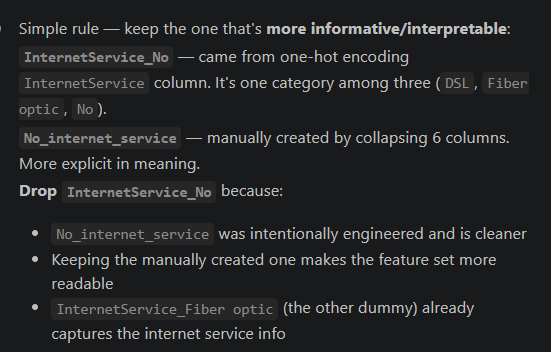  

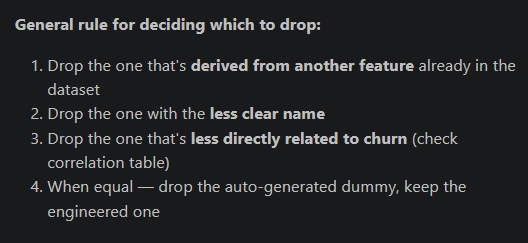

In [165]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

## Machine learning

In [166]:
# We have a class imbalance problem
# Given your imbalance (27% churners), class weighting + threshold tuning is probably enough — no need for aggressive oversampling yet.
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In churn prediction, recall (and metrics derived from it, like F1) is usually the most important — here’s why:

1️⃣ Business context
Churn prediction is asymmetric in cost:

- False Negative (FN): You predict a customer will not churn, but they actually leave → you miss the chance to intervene and keep them.

- False Positive (FP): You predict a customer will churn, but they stay → you might spend some retention resources unnecessarily.

- Missing churners (FN) usually costs more than wrongly targeting a loyal customer.

Typical priority
- If retention campaigns are cheap → prioritize recall (catch every possible churner).
- If retention campaigns are expensive → balance precision and recall using F1 score or a precision-recall trade-off.
- If business wants a ranking of churn risk → use ROC-AUC or PR-AUC to evaluate the model.


* So when campaigns are cheap, it makes sense to cast a wide net — even if you contact some customers who weren't going to churn, the cost is negligible compared to the revenue saved by catching the real churners.

* If campaigns are expensive (e.g. $200 per customer), then wasting them on non-churners hurts — so you need to be more precise about who you target, hence balancing precision and recall with F1.

In [167]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import pandas as pd
import time

# Prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [168]:
# Lower than 0.5 to boost recall (see next to choose the right value)
THRESHOLD = 0.3

### RandomForest Classifier

In [169]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # Handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# rf is the trained RandomForest model object.
# It holds all the learned weights/trees from fitting on the training data.
# After .fit(), rf contains everything the model learned.
# Then rf.predict_proba(X_test) uses those learned weights to output probabilities on new data.

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [170]:
import time
# Prediction timer
start_pred_rf = time.time()
# Random Forest Classification Report
proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time_rf = time.time() - start_pred_rf
print(f"⏱ Prediction time: {pred_time_rf:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

⏱ Prediction time: 0.0953 seconds
              precision    recall  f1-score   support

           0      0.886     0.770     0.824      1035
           1      0.532     0.725     0.614       374

    accuracy                          0.758      1409
   macro avg      0.709     0.747     0.719      1409
weighted avg      0.792     0.758     0.768      1409



→ You’re now catching 72.5% of actual churners with RandomForest

#### Below is finding best probability cutoff for classifying a customer as "churn".   

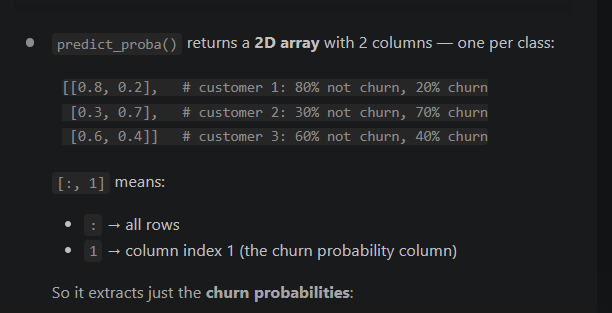  

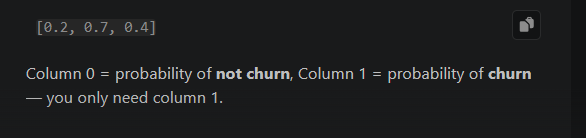  


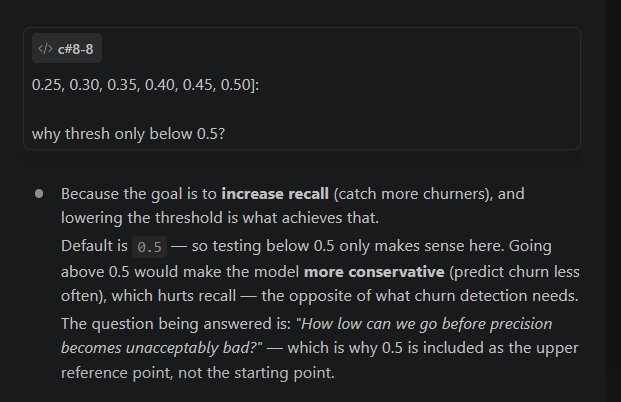   

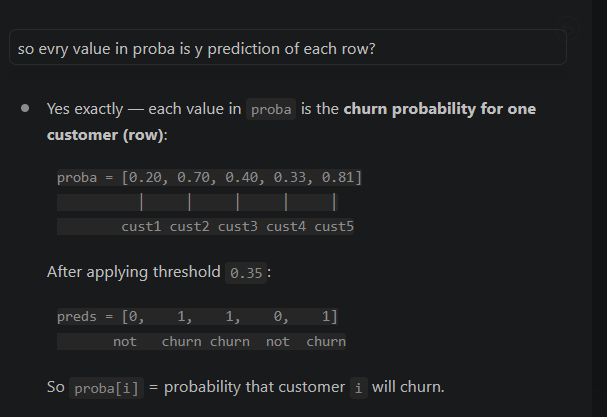   


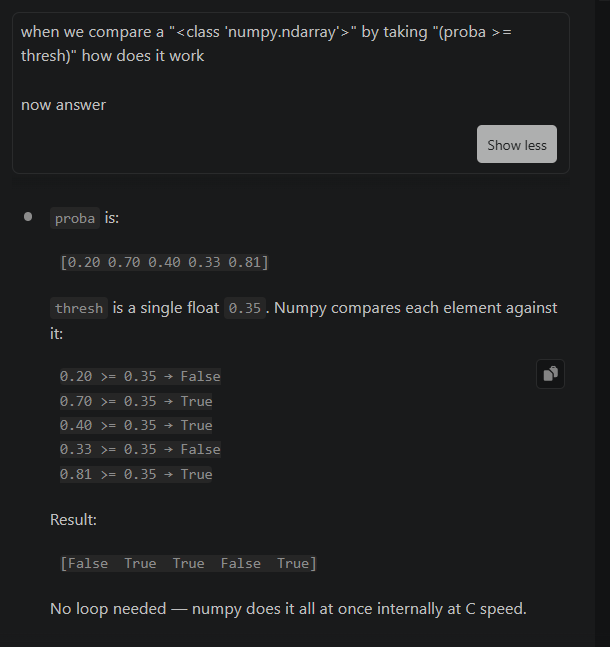  


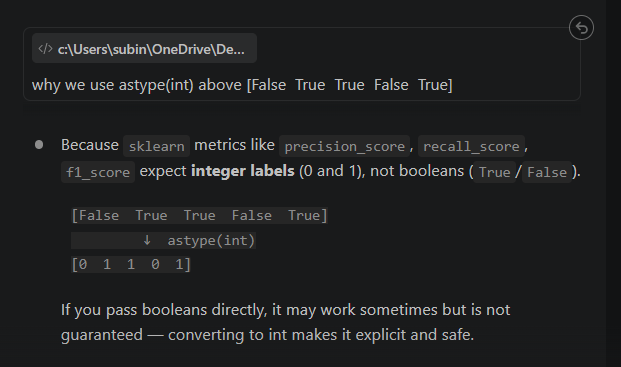   

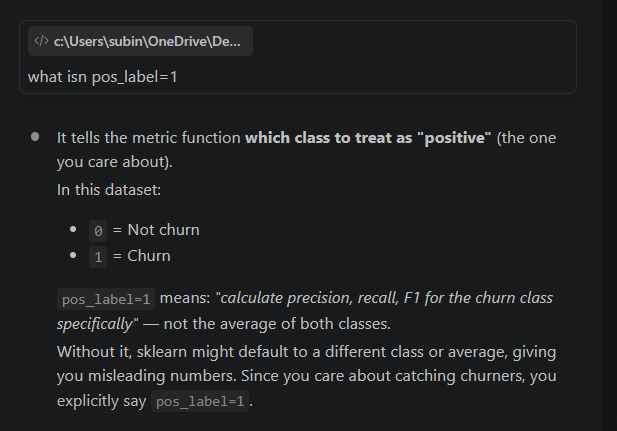  

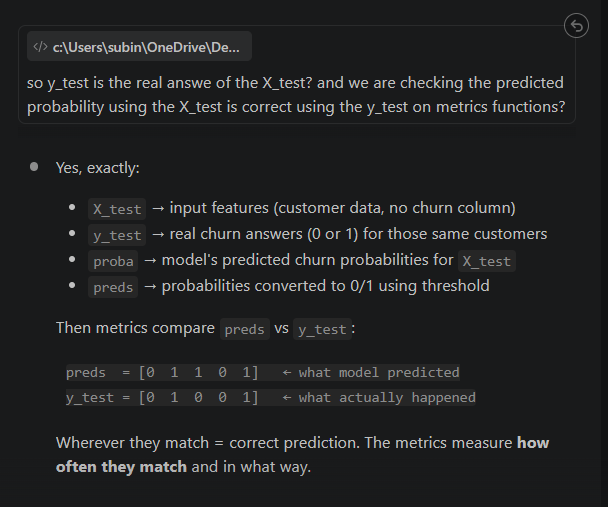  

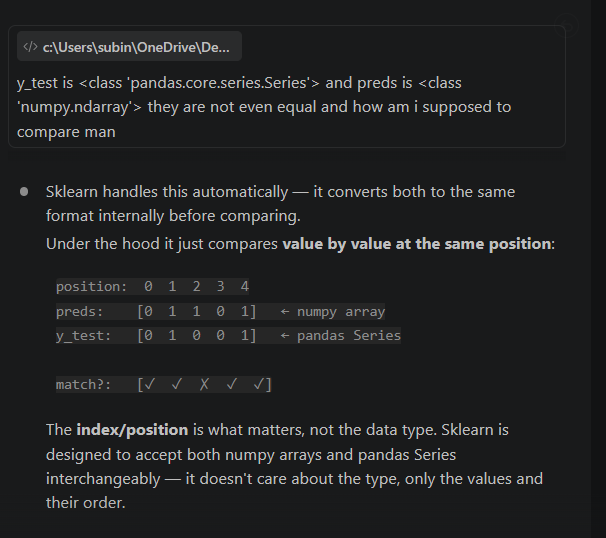  



y_test = [0  1  0  0  1  1  0  1]   ← real answers  
preds  = [0  1  1  0  1  0  0  1]   ← model predictions  

## Confusion Matrix:

TP = 3  (predicted 1, actually 1) → positions 1, 4, 7  
FP = 1  (predicted 1, actually 0) → position 2  
TN = 3  (predicted 0, actually 0) → positions 0, 3, 6  
FN = 1  (predicted 0, actually 1) → position 5  

## Precision_1 (PPV)

TP / (TP + FP) = 3 / (3+1) = 0.75  
Of all predicted churn → 75% actually churned  

## Recall_1 (TPR / Sensitivity)

TP / (TP + FN) = 3 / (3+1) = 0.75  
Of all actual churn → caught 75%  

## Precision_0 (NPV)

TN / (TN + FN) = 3 / (3+1) = 0.75
Of all predicted not churn → 75% actually didn't churn


## Recall_0 (TNR / Specificity)

TN / (TN + FP) = 3 / (3+1) = 0.75
Of all actual not churn → correctly identified 75%





In [171]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]
print(type(proba))

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    # print(preds)
    # print(type(preds))
    prec = precision_score(y_test, preds, pos_label=1)
    # print(type(y_test))
    # print(y_test)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

<class 'numpy.ndarray'>
Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.505   0.791   0.617   
0.3     0.532   0.725   0.614   
0.35    0.549   0.671   0.604   
0.4     0.573   0.620   0.596   
0.45    0.597   0.551   0.573   
0.5     0.624   0.492   0.550   


### LightGBM classifier

In [172]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001648 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
⏱ Training time: 1.39 seconds


In [173]:
# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Prediction time: 0.0142 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733     0.748      1409



→ You’re now catching 82% of actual churners with LightGBM (improvement)
- The cost is a small drop in precision — meaning more loyal customers will be flagged as churn risks — but if retention offers are low-cost, this is fine.

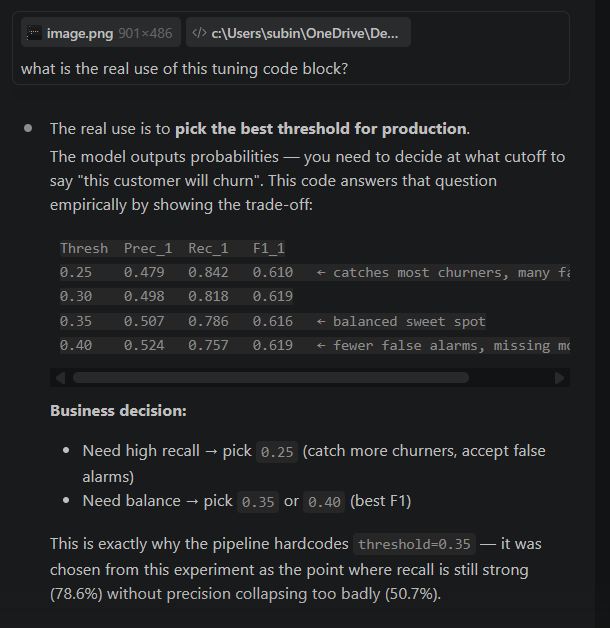

In [174]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


### XGBoost Classifier

In [175]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

⏱ Training time: 0.74 seconds


In [176]:
# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Prediction time: 0.0106 seconds
              precision    recall  f1-score   support

           0      0.913     0.693     0.788      1035
           1      0.490     0.818     0.613       374

    accuracy                          0.726      1409
   macro avg      0.702     0.755     0.701      1409
weighted avg      0.801     0.726     0.742      1409



In [177]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.473   0.848   0.607   
0.3     0.490   0.818   0.613   
0.35    0.503   0.783   0.612   
0.4     0.518   0.759   0.616   
0.45    0.530   0.725   0.612   
0.5     0.543   0.690   0.608   


### ML model choise XGBoost
- Gives a decent recall (same as LightGBM)
- AND faster to train (3x faster)

## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

* direction="maximize" tells Optuna to find hyperparameters that increase the return value of objective(). Since objective() returns recall_score — Optuna keeps trying different hyperparameter combinations across 30 trials, always pushing towards higher recall. If it were direction="minimize" it would minimize the return value — used for metrics like loss or error where lower is better.   


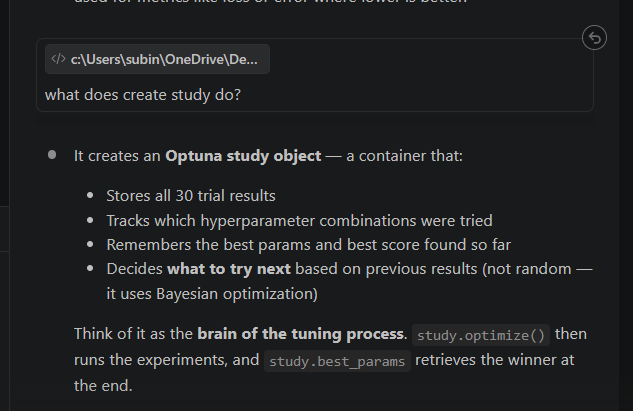   

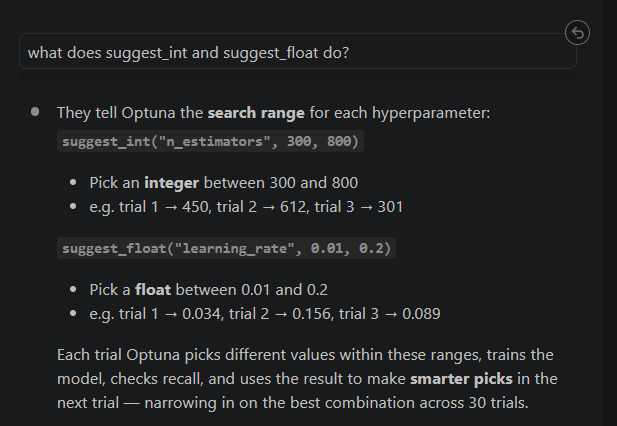  

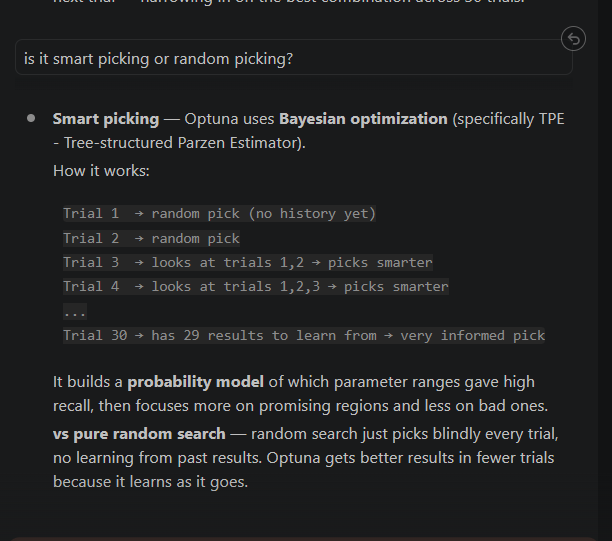

In [178]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # Optimize recall for churners

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

[I 2026-06-21 01:14:03,907] A new study created in memory with name: no-name-9319b669-8e1c-4023-8bca-be61848c7f57
[I 2026-06-21 01:14:04,402] Trial 0 finished with value: 0.8983957219251337 and parameters: {'n_estimators': 747, 'learning_rate': 0.1100465444263847, 'max_depth': 5, 'subsample': 0.5374871957825942, 'colsample_bytree': 0.6347245467217486, 'min_child_weight': 9, 'gamma': 4.543901637425643, 'reg_alpha': 1.3007739532936713, 'reg_lambda': 3.7088453267413657}. Best is trial 0 with value: 0.8983957219251337.
[I 2026-06-21 01:14:04,645] Trial 1 finished with value: 0.8983957219251337 and parameters: {'n_estimators': 412, 'learning_rate': 0.17219681335069412, 'max_depth': 9, 'subsample': 0.545907226520367, 'colsample_bytree': 0.9759030005835572, 'min_child_weight': 10, 'gamma': 4.8403611799328745, 'reg_alpha': 3.37266814085535, 'reg_lambda': 4.349799109320756}. Best is trial 0 with value: 0.8983957219251337.
[I 2026-06-21 01:14:04,937] Trial 2 finished with value: 0.84491978609625

In [179]:
print("Best Params:", study.best_params)
print("Best Params Length:", len(study.best_params))
print("Best Recall:", study.best_value)

Best Params: {'n_estimators': 528, 'learning_rate': 0.08071203562323535, 'max_depth': 4, 'subsample': 0.9936632190937452, 'colsample_bytree': 0.6667329458269414, 'min_child_weight': 7, 'gamma': 4.394504863201402, 'reg_alpha': 3.951626506643551, 'reg_lambda': 0.9840239004365291}
Best Params Length: 9
Best Recall: 0.9224598930481284


In [180]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

Scale Pos Weight: 2.77


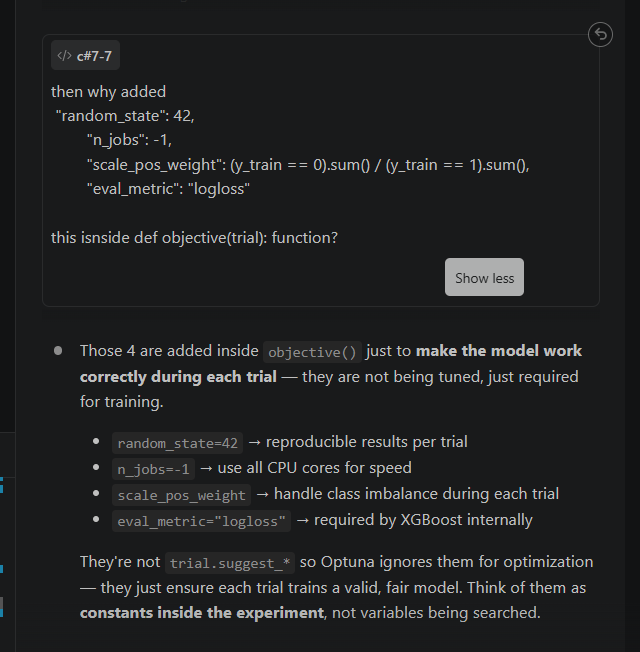  

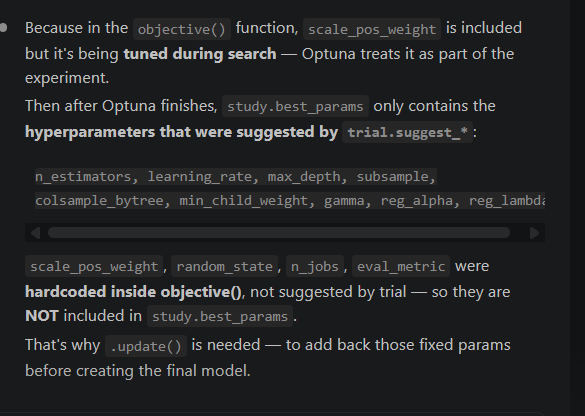


# MULTICOLLINEARITY MEANS BOTH VARIABLES GIVE SAME INFORMATION, WHICH MAKE THE MODEL REDUNTANT

In [181]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create model from best params
xgb = XGBClassifier(**best_params)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

⏱ Training time: 0.99 seconds


In [182]:
# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Prediction time: 0.0542 seconds
              precision    recall  f1-score   support

           0      0.952     0.558     0.704      1035
           1      0.430     0.922     0.587       374

    accuracy                          0.655      1409
   macro avg      0.691     0.740     0.645      1409
weighted avg      0.814     0.655     0.673      1409



In [183]:
# import mlflow
# import mlflow.sklearn  # or mlflow.xgboost
# from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
# import time
# import os

# # Force MLflow to always use the project root's mlruns folder
# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# mlflow.set_tracking_uri(f"file://{project_root}/mlruns")
# mlflow.set_experiment("Telco Churn - XGBoost")

# with mlflow.start_run():
#     # Calculate scale_pos_weight
#     scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

#     # Best params from Optuna
#     best_params = study.best_params
#     best_params.update({
#         "random_state": 42,
#         "n_jobs": -1,
#         "scale_pos_weight": scale_pos_weight,
#         "eval_metric": "logloss"
#     })

#     # Log parameters
#     mlflow.log_params(best_params)

#     # Training timer
#     start_train = time.time()
#     xgb = XGBClassifier(**best_params)
#     xgb.fit(X_train, y_train)
#     train_time = time.time() - start_train
#     mlflow.log_metric("train_time", train_time)

#     # Prediction
#     start_pred = time.time()
#     proba = xgb.predict_proba(X_test)[:, 1]
#     y_pred = (proba >= THRESHOLD).astype(int)
#     pred_time = time.time() - start_pred
#     mlflow.log_metric("pred_time", pred_time)

#     # Metrics
#     precision = precision_score(y_test, y_pred, pos_label=1)
#     recall = recall_score(y_test, y_pred, pos_label=1)
#     f1 = f1_score(y_test, y_pred, pos_label=1)
#     auc = roc_auc_score(y_test, proba)

#     mlflow.log_metric("precision", precision)
#     mlflow.log_metric("recall", recall)
#     mlflow.log_metric("f1", f1)
#     mlflow.log_metric("roc_auc", auc)

#     # Save model
#     mlflow.xgboost.log_model(xgb, "model")

#     print(classification_report(y_test, y_pred, digits=3))

In [184]:
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"Project root: {project_root}")

Project root: c:\Users\subin\OneDrive\Desktop\telco-churn-mlops-pipeline


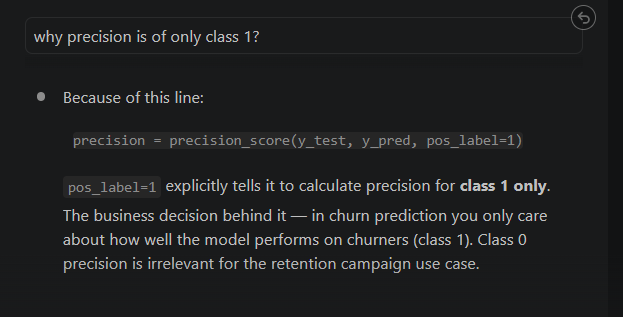  

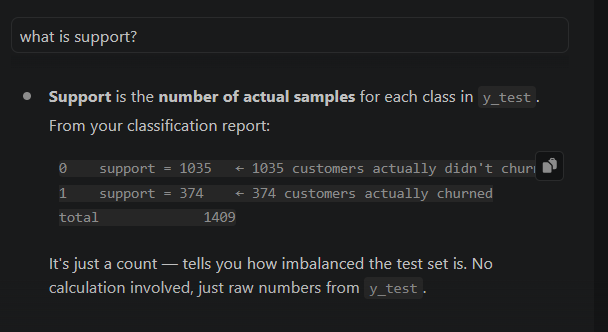

In [185]:
import mlflow
import mlflow.xgboost
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
from pathlib import Path
import time
import os

# project_root = "C:/Users/subin/OneDrive/Desktop/telco-churn-mlops-pipeline"
# Path(project_root, "mlruns") → C:/Users/subin/OneDrive/Desktop/telco-churn-mlops-pipeline/mlruns

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

mlruns_path = Path(project_root, "mlruns")
mlruns_path.mkdir(exist_ok=True)
(mlruns_path / ".trash").mkdir(exist_ok=True)

os.environ["MLFLOW_TRACKING_URI"] = mlruns_path.as_uri()  # ← prevents notebooks/mlruns
mlflow.set_tracking_uri(mlruns_path.as_uri())
# .as_uri() → file:///C:/Users/subin/OneDrive/Desktop/telco-churn-mlops-pipeline/mlruns

mlflow.set_experiment("Telco lChurn - XGBoost")

# The `with` statement ensures the run is automatically closed when the block finishes — even if an error occurs.
# Without it, you'd have to manually call mlflow.end_run().
# Each start_run() creates a unique run ID in the experiment, so every execution is tracked separately and comparable in the MLflow UI.
with mlflow.start_run():
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })
    # Save params to MLflow
    mlflow.log_params(best_params)

    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    # Log training time to MLflow
    mlflow.log_metric("train_time", train_time)
    
    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred 
    # Log prediction time to MLflow
    mlflow.log_metric("pred_time", pred_time)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)
    # Log metrics to MLflow
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)
    # Save model
    mlflow.xgboost.log_model(xgb, "model")
    print(classification_report(y_test, y_pred, digits=4))


c:\Users\subin\OneDrive\Desktop\telco-churn-mlops-pipeline\venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [01:14:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)


              precision    recall  f1-score   support

           0     0.9522    0.5585    0.7040      1035
           1     0.4302    0.9225    0.5867       374

    accuracy                         0.6551      1409
   macro avg     0.6912    0.7405    0.6454      1409
weighted avg     0.8137    0.6551    0.6729      1409



c:\Users\subin\OneDrive\Desktop\telco-churn-mlops-pipeline\venv\Lib\site-packages\_distutils_hack\__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
c:\Users\subin\OneDrive\Desktop\telco-churn-mlops-pipeline\venv\Lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


# FOLDER STRUCTURE
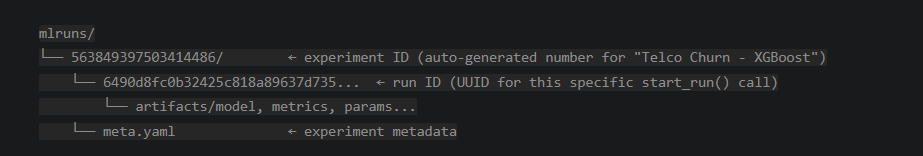

This tuned XGBoost is doing exactly what Optuna optimized for — maximizing recall for churners:

- Recall (class 1): 0.928 ✅ (highest we’ve seen so far)

- Precision (class 1): 0.442 (low — many loyal customers are being flagged)

- F1 (class 1): 0.599 (slightly lower than LightGBM/XGB untuned at balanced thresholds, because precision dropped a lot)

Interpretation

- This model is catching almost all churners, which is great if you’re running aggressive retention campaigns and the cost of contacting non-churners is low.

- But the low precision means more than half of the people you target won’t actually churn.